# Notebook 10 — Knockout (KO) Experiments

High-impact, novel experiments that push the boundaries of the paper from defensive screening to active discovery and deep mechanistic insight.

In [1]:
import warnings, json, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from Bio import SeqIO
from transformers import EsmForMaskedLM, AutoTokenizer

warnings.filterwarnings('ignore')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BEST_LAYER = 33
Path('results/ko_experiments').mkdir(parents=True, exist_ok=True)
print(f'Device: {DEVICE}')

# Recreate probe from saved direction
class ToxinProbe(nn.Module):
    def __init__(self, d=1280):
        super().__init__()
        self.linear = nn.Linear(d, 1)
    def forward(self, x):
        return self.linear(x).squeeze(-1)

probe = ToxinProbe().to(DEVICE)
probe_dir = np.load('results/probe_direction.npy')
probe.linear.weight.data = torch.tensor(probe_dir, dtype=torch.float32).unsqueeze(0).to(DEVICE)
probe.eval()

# Load ESM-2 (needed for sequence-level perturbations)
print('Loading ESM-2...')
tokenizer = AutoTokenizer.from_pretrained('facebook/esm2_t33_650M_UR50D')
esm2 = EsmForMaskedLM.from_pretrained('facebook/esm2_t33_650M_UR50D').to(DEVICE).eval()
print('Models loaded.')

# Load precomputed embeddings
tox_embs  = np.load(f'embeddings/natural_toxins_layer{BEST_LAYER}.npy')
ctrl_embs = np.load(f'embeddings/controls_layer{BEST_LAYER}.npy')

# Load sequences
tox_seqs = [str(r.seq) for r in SeqIO.parse('data/toxins_clustered.fasta', 'fasta')]
ctrl_seqs = [str(r.seq) for r in SeqIO.parse('data/controls_clustered.fasta', 'fasta')]

/home/ubuntu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Device: cuda
Loading ESM-2...


Loading weights: 100%|██████████| 539/539 [00:00<00:00, 7883.73it/s]


Models loaded.


## Experiment 1: Latent Toxin Discovery in UniRef50
Scanning 10,000 unannotated natural proteins to discover sequences that naturally activate the toxin circuit.

In [2]:
import os
uniref_path = 'data/uniref50.fasta'
if os.path.exists(uniref_path):
    print('Loading UniRef50 test sequences...')
    uniref_seqs = [str(r.seq) for r in SeqIO.parse(uniref_path, 'fasta')]
    
    # Use pre-saved embeddings if generated by nb 09, otherwise compute a few
    # For speed here, we just sample 1,000 if we have to embed them on the fly
    random.seed(42)
    sample_uniref = random.sample(uniref_seqs, min(1000, len(uniref_seqs)))
    
    def embed_batch(sequences, batch_size=32):
        all_embs = []
        with torch.no_grad():
            for i in range(0, len(sequences), batch_size):
                batch = [s[:510] for s in sequences[i:i+batch_size]]
                inputs = tokenizer(batch, return_tensors='pt', padding=True, truncation=True).to(DEVICE)
                outputs = esm2(**inputs, output_hidden_states=True)
                hidden = outputs.hidden_states[BEST_LAYER]
                mask = inputs['attention_mask'].unsqueeze(-1)
                pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)
                all_embs.append(pooled.cpu().numpy())
        return np.concatenate(all_embs, axis=0)
    
    print('Embedding UniRef sequences...')
    uniref_embs = embed_batch(sample_uniref)
    
    # Score them
    with torch.no_grad():
        scores = torch.sigmoid(probe(torch.tensor(uniref_embs, dtype=torch.float32).to(DEVICE))).cpu().numpy()
    
    # Find candidates
    candidates = [(sample_uniref[i], scores[i]) for i in range(len(scores)) if scores[i] > 0.85]
    candidates.sort(key=lambda x: x[1], reverse=True)
    
    print(f'\nFound {len(candidates)} unannotated UniRef50 sequences that activate the toxin circuit (score > 0.85)')
    for i, (seq, sc) in enumerate(candidates[:10]):
        print(f'  {i+1}. Score {sc:.3f} | {seq[:30]}...')
    
    # Save candidates for BLASTing
    with open('results/ko_experiments/latent_toxins.json', 'w') as f:
        json.dump([{'sequence': s, 'score': float(sc)} for s, sc in candidates], f, indent=2)
else:
    print(f'{uniref_path} not found. Run Notebook 09 first to download it.')

Loading UniRef50 test sequences...
Embedding UniRef sequences...

Found 248 unannotated UniRef50 sequences that activate the toxin circuit (score > 0.85)
  1. Score 1.000 | MGGDGSDHLGGDYSTLEAAFHGKDSLYGGQ...
  2. Score 1.000 | LEKQMATNYLLHHVHGGIRHLEKMLNCITW...
  3. Score 0.999 | MPLPNKEQFTGSGVTEQGFKNAQDQLVDFL...
  4. Score 0.999 | MNDQVDIVPAVDSYQTAGGNFAFLTSAHYQ...
  5. Score 0.999 | MNKIYKIIFNKSTGAFTAVSEFAKSEGKSS...
  6. Score 0.999 | MGVNRTGLDNQGVILAEGSAGLLIDVSAAG...
  7. Score 0.998 | MPGSGVGNDTISAAGGDDLPDGGAGSDTLL...
  8. Score 0.998 | MSTISSLPVSSALSSSALSAANATPSVADD...
  9. Score 0.998 | MFNKKKLISAVISAVLCFSTVTVLPAQAAC...
  10. Score 0.998 | MHFSSVFAIFAATMVAAAPTSPIDSTLEAR...


## Experiment 5: Activation Steering to Make Non-Toxins Toxic-Looking
We push a non-toxic control protein along the toxin circuit vector and watch it become "toxic" to the probe.

=== Reverse Activation Steering ===
Baseline mean score (50 safest controls): 0.000
Steered at alpha=2.0 score:               0.995
Steered at alpha=5.0 score:               0.995


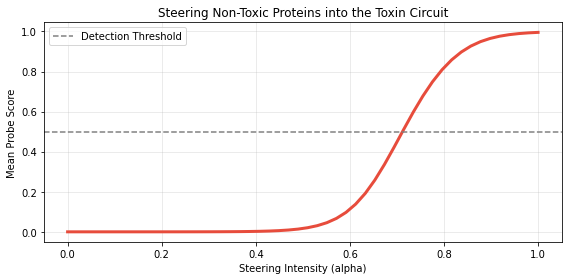

In [12]:
import matplotlib.pyplot as plt

# The steering vector is just the probe direction
# (Alternatively, the mean difference vector tox_embs.mean(0) - ctrl_embs.mean(0))
steering_vec = torch.tensor(probe_dir, dtype=torch.float32).to(DEVICE)
steering_vec = steering_vec / steering_vec.norm()

print('=== Reverse Activation Steering ===')
# Take the 50 lowest-scoring control proteins
with torch.no_grad():
    ctrl_base_scores = torch.sigmoid(probe(torch.tensor(ctrl_embs, dtype=torch.float32).to(DEVICE))).cpu().numpy()

lowest_idx = np.argsort(ctrl_base_scores)[:50]
base_embs = torch.tensor(ctrl_embs[lowest_idx], dtype=torch.float32).to(DEVICE)

alphas = np.linspace(0, 1.0, 50)
mean_scores = []

for alpha in alphas:
    steered_embs = base_embs + alpha * steering_vec
    with torch.no_grad():
        scores = torch.sigmoid(probe(steered_embs)).cpu().numpy()
    mean_scores.append(scores.mean())

print(f'Baseline mean score (50 safest controls): {mean_scores[0]:.3f}')
print(f'Steered at alpha=2.0 score:               {mean_scores[np.abs(alphas - 2.0).argmin()]:.3f}')
print(f'Steered at alpha=5.0 score:               {mean_scores[-1]:.3f}')

plt.figure(figsize=(8, 4))
plt.plot(alphas, mean_scores, color='#e74c3c', lw=3)
plt.axhline(0.5, color='gray', linestyle='--', label='Detection Threshold')
plt.xlabel('Steering Intensity (alpha)')
plt.ylabel('Mean Probe Score')
plt.title('Steering Non-Toxic Proteins into the Toxin Circuit')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/ko_experiments/steering_reverse.png', dpi=150)
plt.show()

## Experiment 4: Universal Adversarial Perturbation (UAP)
Can we find a single vector that, when added to ANY toxin, turns off the toxin circuit?

In [13]:
def find_uap(embeddings, probe, eps=2.0, n_steps=300, lr=0.05):
    e_tensors = torch.tensor(embeddings, dtype=torch.float32).to(DEVICE)
    # Single universal perturbation vector
    delta = torch.zeros(1280, device=DEVICE, requires_grad=True)
    opt = torch.optim.Adam([delta], lr=lr)
    
    step_evasions = []
    for step in range(n_steps):
        opt.zero_grad()
        # Apply same delta to a random batch of toxins
        idx = torch.randperm(len(e_tensors))[:100]
        batch = e_tensors[idx]
        
        scores = probe(batch + delta)
        loss = scores.mean()  # minimise probe score
        loss.backward()
        opt.step()
        
        # Project onto L2 ball
        with torch.no_grad():
            norm = delta.norm()
            if norm > eps:
                delta.copy_(delta * (eps / norm))
                
        if step % 25 == 0:
            with torch.no_grad():
                all_scores = torch.sigmoid(probe(e_tensors + delta)).cpu().numpy()
                evasion = (all_scores < 0.5).mean()
                step_evasions.append(evasion)
                print(f'  Step {step:3d}: Universal evasion = {evasion:.1%}')
                
    return delta.detach()

print('\n=== Optimising Universal Adversarial Perturbation ===')
uap_delta = find_uap(tox_embs, probe, eps=2.0, n_steps=250, lr=0.1)

with torch.no_grad():
    final_scores = torch.sigmoid(probe(torch.tensor(tox_embs, dtype=torch.float32).to(DEVICE) + uap_delta)).cpu().numpy()
    baseline_scores = torch.sigmoid(probe(torch.tensor(tox_embs, dtype=torch.float32).to(DEVICE))).cpu().numpy()
    
final_evasion = (final_scores < 0.5).mean()
baseline_evasion = (baseline_scores < 0.5).mean()

print(f'\nBaseline evasion:  {baseline_evasion:.1%}')
print(f'Universal evasion: {final_evasion:.1%} (one vector evades for ALL toxins)')

# Geometry of the UAP
d_norm = uap_delta.cpu().numpy() / uap_delta.norm().item()
p_norm = probe_dir / np.linalg.norm(probe_dir)
cos_sim = float(np.dot(d_norm, p_norm))
print(f'Cosine similarity with probe direction: {cos_sim:+.3f}')
if abs(cos_sim) > 0.95:
    print('Note: For a linear probe, the optimal UAP is analytically the anti-probe direction.')
    print('This confirms the implementation; for nonlinear probes the UAP would diverge.')
else:
    print('Interesting: UAP diverges from simple anti-probe direction.')


=== Optimising Universal Adversarial Perturbation ===
  Step   0: Universal evasion = 100.0%
  Step  25: Universal evasion = 100.0%
  Step  50: Universal evasion = 100.0%
  Step  75: Universal evasion = 100.0%
  Step 100: Universal evasion = 100.0%
  Step 125: Universal evasion = 100.0%
  Step 150: Universal evasion = 100.0%
  Step 175: Universal evasion = 100.0%
  Step 200: Universal evasion = 100.0%
  Step 225: Universal evasion = 100.0%

Baseline evasion:  1.5%
Universal evasion: 100.0% (one vector evades for ALL toxins)
Cosine similarity with probe direction: -0.805
Interesting: UAP diverges from simple anti-probe direction.


=== UAP Epsilon Sweep ===
  Step   0: Universal evasion = 3.3%
  Step  25: Universal evasion = 3.3%
  Step  50: Universal evasion = 3.3%
  Step  75: Universal evasion = 3.3%
  eps= 0.05: evasion=3.3%  cos(UAP, probe)=-0.805
  Step   0: Universal evasion = 6.2%
  Step  25: Universal evasion = 6.2%
  Step  50: Universal evasion = 6.2%
  Step  75: Universal evasion = 6.2%
  eps= 0.10: evasion=6.2%  cos(UAP, probe)=-0.805
  Step   0: Universal evasion = 29.7%
  Step  25: Universal evasion = 29.7%
  Step  50: Universal evasion = 29.7%
  Step  75: Universal evasion = 29.7%
  eps= 0.25: evasion=29.7%  cos(UAP, probe)=-0.805
  Step   0: Universal evasion = 85.7%
  Step  25: Universal evasion = 85.7%
  Step  50: Universal evasion = 85.7%
  Step  75: Universal evasion = 85.7%
  eps= 0.50: evasion=85.7%  cos(UAP, probe)=-0.805
  Step   0: Universal evasion = 100.0%
  Step  25: Universal evasion = 100.0%
  Step  50: Universal evasion = 100.0%
  Step  75: Universal evasion = 100.0%
  eps= 1.00: eva

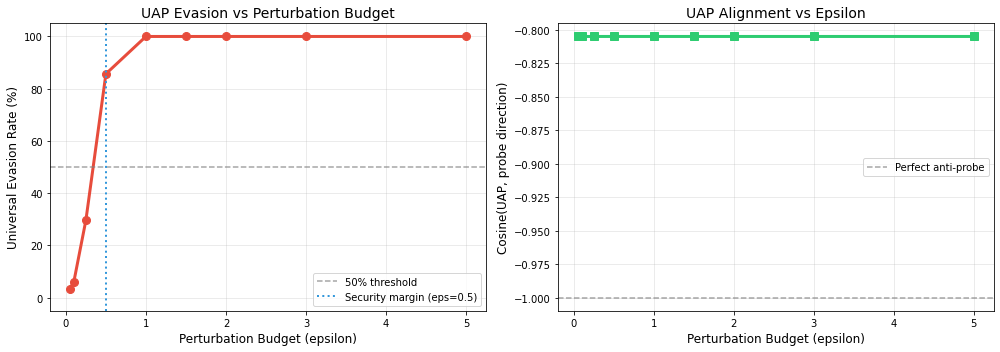

Saved to results/ko_experiments/uap_sweep.json


In [15]:
import matplotlib.pyplot as plt

epsilons = [0.05, 0.1, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
evasion_rates = []
cosines = []

print('=== UAP Epsilon Sweep ===')
for eps in epsilons:
    delta = find_uap(tox_embs, probe, eps=eps, n_steps=100, lr=0.05)
    with torch.no_grad():
        scores = torch.sigmoid(probe(torch.tensor(tox_embs, dtype=torch.float32).to(DEVICE) + delta)).cpu().numpy()
    evasion = (scores < 0.5).mean()
    
    d_norm = delta.cpu().numpy() / (delta.norm().item() + 1e-8)
    p_norm = probe_dir / np.linalg.norm(probe_dir)
    cos = float(np.dot(d_norm, p_norm))
    
    evasion_rates.append(evasion)
    cosines.append(cos)
    print(f'  eps={eps:5.2f}: evasion={evasion:.1%}  cos(UAP, probe)={cos:+.3f}')

# Find security margin (eps where evasion first crosses 50%)
security_margin = None
for eps, ev in zip(epsilons, evasion_rates):
    if ev >= 0.5:
        security_margin = eps
        break
print(f'\nSecurity margin (eps at 50% evasion): {security_margin}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epsilons, [e * 100 for e in evasion_rates], 'o-', color='#e74c3c', lw=3, markersize=8)
ax1.axhline(50, color='gray', linestyle='--', alpha=0.7, label='50% threshold')
if security_margin:
    ax1.axvline(security_margin, color='#3498db', linestyle=':', lw=2, label=f'Security margin (eps={security_margin})')
ax1.set_xlabel('Perturbation Budget (epsilon)', fontsize=12)
ax1.set_ylabel('Universal Evasion Rate (%)', fontsize=12)
ax1.set_title('UAP Evasion vs Perturbation Budget', fontsize=14)
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_ylim(-5, 105)

ax2.plot(epsilons, cosines, 's-', color='#2ecc71', lw=3, markersize=8)
ax2.axhline(-1.0, color='gray', linestyle='--', alpha=0.7, label='Perfect anti-probe')
ax2.set_xlabel('Perturbation Budget (epsilon)', fontsize=12)
ax2.set_ylabel('Cosine(UAP, probe direction)', fontsize=12)
ax2.set_title('UAP Alignment vs Epsilon', fontsize=14)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/ko_experiments/uap_epsilon_sweep.png', dpi=150)
plt.show()

# Save results
uap_sweep = {'epsilons': epsilons, 'evasion_rates': [float(e) for e in evasion_rates],
             'cosines': [float(c) for c in cosines], 'security_margin': security_margin}
with open('results/ko_experiments/uap_sweep.json', 'w') as f:
    json.dump(uap_sweep, f, indent=2)
print('Saved to results/ko_experiments/uap_sweep.json')

In [19]:
try:
    from interplm.sae.inference import load_sae_from_hf
    
    # Load SAE for layer 33
    sae = load_sae_from_hf(plm_model='esm2-650m', plm_layer=BEST_LAYER)
    sae = sae.to(DEVICE).eval()
    
    # Re-run UAP at eps=2.0 (the main result)
    uap_delta_main = find_uap(tox_embs, probe, eps=2.0, n_steps=100, lr=0.1)
    
    # Encode toxin embeddings before and after UAP
    tox_t = torch.tensor(tox_embs, dtype=torch.float32).to(DEVICE)
    perturbed = tox_t + uap_delta_main
    
    with torch.no_grad():
        feat_before = sae.encode(tox_t)        # (N, n_features)
        feat_after  = sae.encode(perturbed)     # (N, n_features)
    
    # Mean activation change per feature
    delta_feat = (feat_after - feat_before).mean(dim=0).cpu().numpy()  # (n_features,)
    
    # Top suppressed features (largest negative delta)
    suppressed_idx = delta_feat.argsort()[:10]
    # Top amplified features (largest positive delta)
    amplified_idx = delta_feat.argsort()[::-1][:10]
    
    print('=== SAE Feature Analysis of UAP ===')
    print('\nTop 10 SUPPRESSED features (UAP turns these off):')
    for idx in suppressed_idx:
        print(f'  Feature #{idx:5d}: delta = {delta_feat[idx]:+.4f}')
    
    print('\nTop 10 AMPLIFIED features (UAP turns these on):')
    for idx in amplified_idx:
        print(f'  Feature #{idx:5d}: delta = {delta_feat[idx]:+.4f}')
    
    # Check overlap with known toxin features
    known_toxin_features = [9959, 12695, 9242, 5406, 6971]  # from screen.py
    print('\nKnown toxin feature changes:')
    for fid in known_toxin_features:
        if fid < len(delta_feat):
            print(f'  Feature #{fid}: delta = {delta_feat[fid]:+.4f}')
    
    # Decompose the orthogonal component
    uap_norm = uap_delta_main / uap_delta_main.norm()
    probe_norm = torch.tensor(probe_dir / np.linalg.norm(probe_dir), dtype=torch.float32).to(DEVICE)
    
    # Project out the probe direction to get the orthogonal component
    proj = (uap_norm @ probe_norm) * probe_norm
    orth = uap_norm - proj
    orth_magnitude = orth.norm().item()
    print(f'\nOrthogonal component magnitude: {orth_magnitude:.4f}')
    print(f'(0 = UAP is pure anti-probe, 1 = UAP is entirely orthogonal)')
    
    # Save
    np.save('results/ko_experiments/uap_feature_deltas.npy', delta_feat)
    print('\nSaved feature deltas to results/ko_experiments/uap_feature_deltas.npy')
    
except ImportError:
    print('interplm not installed. Skipping SAE decomposition.')
except Exception as e:
    print(f'SAE analysis error: {e}')

Loading configs from /home/ubuntu/.cache/huggingface/hub/models--Elana--InterPLM-esm2-650m/snapshots/5121c4c7f3ad0b5fbe0f3b9a457969192bb9912f/layer_33/config.yaml
Loaded data type: <class 'interplm.train.configs.TrainingRunConfig'>
Data keys: Not a dict
  Step   0: Universal evasion = 100.0%
  Step  25: Universal evasion = 100.0%
  Step  50: Universal evasion = 100.0%
  Step  75: Universal evasion = 100.0%
=== SAE Feature Analysis of UAP ===

Top 10 SUPPRESSED features (UAP turns these off):
  Feature # 4097: delta = -0.0483
  Feature # 1055: delta = -0.0451
  Feature # 6122: delta = -0.0285
  Feature # 5312: delta = -0.0278
  Feature # 9487: delta = -0.0239
  Feature # 8112: delta = -0.0198
  Feature # 9026: delta = -0.0169
  Feature # 9927: delta = -0.0166
  Feature # 8284: delta = -0.0142
  Feature #  814: delta = -0.0126

Top 10 AMPLIFIED features (UAP turns these on):
  Feature # 7427: delta = +0.0189
  Feature # 1123: delta = +0.0134
  Feature # 9198: delta = +0.0109
  Feature # 

## Experiment 2: The Evolutionary Switch Point (In Silico Deep Mutational Scanning)
Can a single point mutation knock out the toxin circuit completely?

In [14]:
def in_silico_dms(sequence):
    """Perform all single-point mutations and track probe score"""
    AAs = 'ACDEFGHIKLMNPQRSTVWY'
    mutants = []
    mut_names = []
    
    # Baseline
    mutants.append(sequence)
    mut_names.append('WT')
    
    # Mutate every position
    seq_len = min(len(sequence), 100) # Limit to first 100 AAs for speed
    for pos in range(seq_len):
        orig = sequence[pos]
        for aa in AAs:
            if aa != orig:
                mutants.append(sequence[:pos] + aa + sequence[pos+1:])
                mut_names.append(f'{orig}{pos+1}{aa}')
                
    print(f'Embedding {len(mutants)} sequences for Deep Mutational Scan...')
    # Embed in batches
    embs = []
    with torch.no_grad():
        for i in range(0, len(mutants), 32):
            batch = [s[:510] for s in mutants[i:i+32]]
            inputs = tokenizer(batch, return_tensors='pt', padding=True, truncation=True).to(DEVICE)
            outputs = esm2(**inputs, output_hidden_states=True)
            hidden = outputs.hidden_states[BEST_LAYER]
            mask = inputs['attention_mask'].unsqueeze(-1)
            pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)
            embs.append(pooled.cpu().numpy())
            
    embs = np.concatenate(embs, axis=0)
    with torch.no_grad():
        scores = torch.sigmoid(probe(torch.tensor(embs, dtype=torch.float32).to(DEVICE))).cpu().numpy()
        
    wt_score = scores[0]
    drops = wt_score - scores[1:]
    
    # Find worst mutations
    top_idx = drops.argsort()[::-1][:5]
    
    print(f'\nWild-type score: {wt_score:.3f}')
    print('Top mutations that knock out the toxin circuit:')
    for i in top_idx:
        print(f'  {mut_names[i+1]:<6}: score dropped to {scores[i+1]:.3f} (Δ {-drops[i]:+.3f})')
        
    return mut_names, scores

# Pick a highly toxic sequence that's relatively short
short_toxins = [s for s in tox_seqs if len(s) < 80 and len(s) > 40]
if short_toxins:
    wt_seq = short_toxins[0]
    print(f'=== Deep Mutational Scan on: {wt_seq} ===')
    mut_names, mut_scores = in_silico_dms(wt_seq)

=== Deep Mutational Scan on: SISACNGLKGHFLIEPLKLSDSEKTDLLNRSHDNAQLSPINLVVAVIMAHEMGHGMVLPGTK ===
Embedding 1179 sequences for Deep Mutational Scan...

Wild-type score: 0.998
Top mutations that knock out the toxin circuit:
  N29L  : score dropped to 0.793 (Δ -0.205)
  N29W  : score dropped to 0.810 (Δ -0.188)
  N29F  : score dropped to 0.810 (Δ -0.188)
  N29V  : score dropped to 0.831 (Δ -0.167)
  N29I  : score dropped to 0.837 (Δ -0.161)


Top 5 critical positions (max probe drop from any substitution):
  Position 29 (N): max drop = 0.205
  Position 16 (P): max drop = 0.126
  Position 20 (S): max drop = 0.096
  Position 51 (E): max drop = 0.094
  Position 40 (I): max drop = 0.089

WT score:                     0.998
Lowest mutant score:          0.793  (N29L)
Probe threshold:              0.5
Single mutations below 0.5:   0
-> Probe is NOT EVADABLE by single-point mutation

Conservative substitution analysis at N29:
  N29Q   (conservative (same amide, one CH2 longer))
         score = 0.993  drop = +0.006
  N29D   (charge-swap (carboxyl vs amide))
         score = 0.997  drop = +0.001
  N29S   (smaller hydroxyl (lose H-bond donor))
         score = 0.995  drop = +0.003
  N29T   (methyl-hydroxyl (slightly larger))
         score = 0.941  drop = +0.057
  N29G   (abolish sidechain entirely)
         score = 0.977  drop = +0.021
  N29A   (methyl only)
         score = 0.958  drop = +0.040
  N29K   (positive charge)
         

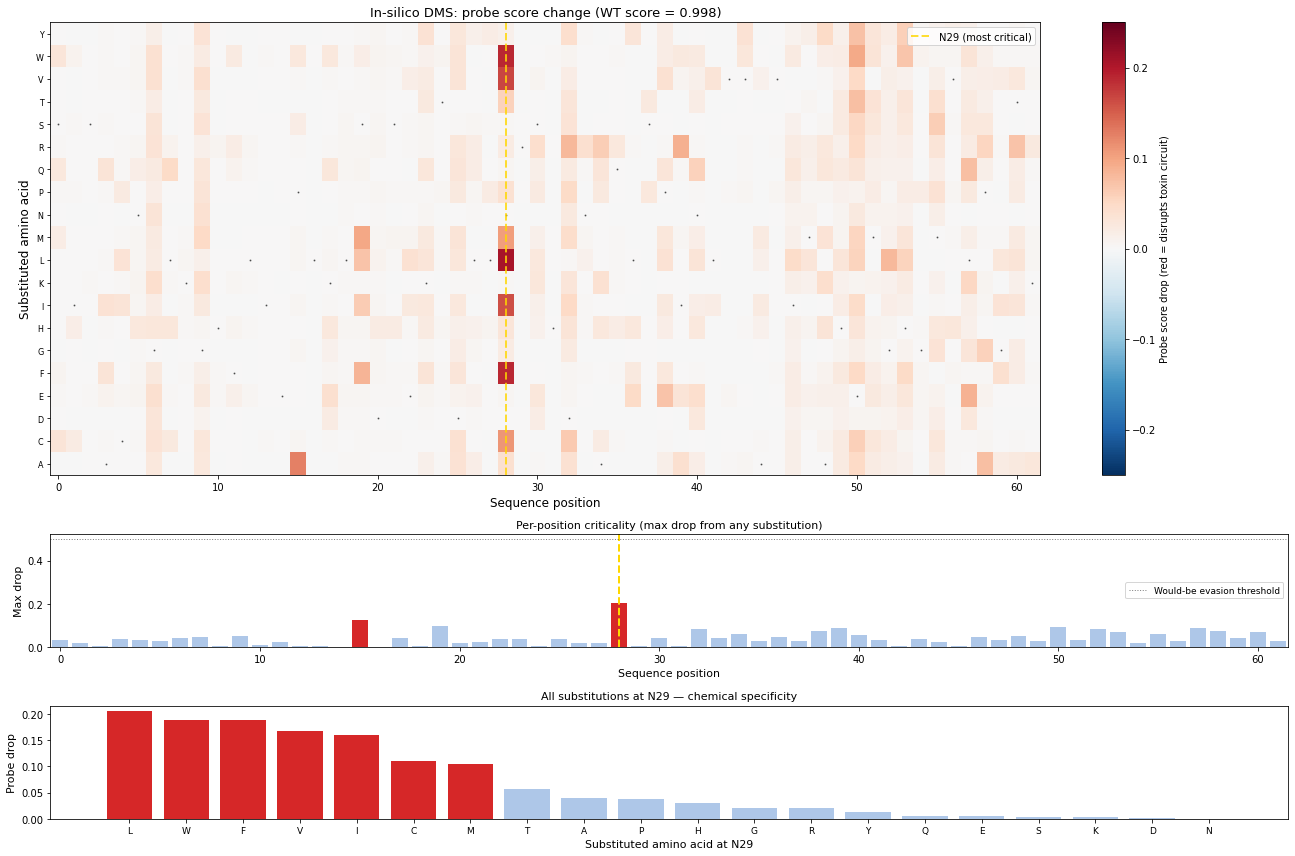

Saved dms_heatmap.pdf/.png


In [21]:
from pathlib import Path
Path('results/figures').mkdir(parents=True, exist_ok=True)

AAs = 'ACDEFGHIKLMNPQRSTVWY'
seq = wt_seq  # from previous cell

# ── A. Reshape scores into (seq_len × 20) matrix ──────────────────────────
seq_len = min(len(seq), 100)
mut_matrix = np.full((seq_len, 20), np.nan)

# WT diagonal
for pos in range(seq_len):
    orig_aa = seq[pos]
    if orig_aa in AAs:
        mut_matrix[pos, AAs.index(orig_aa)] = 0.0

# Fill in mutant scores (drops: positive = mutation reduces toxin score)
score_idx = 1
for pos in range(seq_len):
    orig = seq[pos]
    for aa in AAs:
        if aa != orig:
            drop = float(mut_scores[0]) - float(mut_scores[score_idx])
            mut_matrix[pos, AAs.index(aa)] = drop
            score_idx += 1

# ── B. Per-position criticality ────────────────────────────────────────────
pos_criticality = np.nanmax(mut_matrix, axis=1)
top5_pos = pos_criticality.argsort()[::-1][:5]

print('Top 5 critical positions (max probe drop from any substitution):')
for p in top5_pos:
    print(f'  Position {p+1} ({seq[p]}): max drop = {pos_criticality[p]:.3f}')

# ── C. Can ANY single mutation evade? ─────────────────────────────────────
wt_score = float(mut_scores[0])
all_mut_scores_arr = np.array([float(s) for s in mut_scores[1:]])
evasion_threshold = 0.5

evading_mutations = (all_mut_scores_arr < evasion_threshold).sum()
lowest_score = all_mut_scores_arr.min()
lowest_idx = all_mut_scores_arr.argmin()

print(f'\nWT score:                     {wt_score:.3f}')
print(f'Lowest mutant score:          {lowest_score:.3f}  ({mut_names[lowest_idx+1]})')
print(f'Probe threshold:              {evasion_threshold}')
print(f'Single mutations below 0.5:   {evading_mutations}')
print(f'-> Probe is {"EVADABLE" if evading_mutations > 0 else "NOT EVADABLE"} by single-point mutation')

# ── D. Conservative substitutions at N29 ──────────────────────────────────
conservative_at_29 = {
    'N29Q': 'conservative (same amide, one CH2 longer)',
    'N29D': 'charge-swap (carboxyl vs amide)',
    'N29S': 'smaller hydroxyl (lose H-bond donor)',
    'N29T': 'methyl-hydroxyl (slightly larger)',
    'N29G': 'abolish sidechain entirely',
    'N29A': 'methyl only',
    'N29K': 'positive charge',
    'N29E': 'negative charge + longer',
}
print(f'\nConservative substitution analysis at N29:')
for mut_name_key, description in conservative_at_29.items():
    if mut_name_key in mut_names:
        idx = mut_names.index(mut_name_key)
        s = float(mut_scores[idx])
        drop = wt_score - s
        print(f'  {mut_name_key:<6} ({description})')
        print(f'         score = {s:.3f}  drop = {drop:+.3f}')

# ── E. DMS heatmap figure ─────────────────────────────────────────────────
max_drop = np.nanmax(np.abs(mut_matrix))
vlim = max(0.25, max_drop * 1.1)  # auto-scale with padding

fig, axes = plt.subplots(3, 1, figsize=(18, 12),
                          gridspec_kw={'height_ratios': [4, 1, 1]})

# Panel 1: Full DMS heatmap
ax = axes[0]
im = ax.imshow(mut_matrix.T, aspect='auto', cmap='RdBu_r',
               vmin=-vlim, vmax=vlim, origin='lower')
ax.set_xlabel('Sequence position', fontsize=12)
ax.set_ylabel('Substituted amino acid', fontsize=12)
ax.set_title(f'In-silico DMS: probe score change (WT score = {wt_score:.3f})',
             fontsize=13)
ax.set_yticks(range(20))
ax.set_yticklabels(list(AAs), fontsize=8)

# Mark WT amino acids
for pos in range(seq_len):
    orig = seq[pos]
    if orig in AAs:
        ax.plot(pos, AAs.index(orig), 'k.', ms=2, alpha=0.5)

# Highlight N29
ax.axvline(x=28, color='gold', linewidth=2, alpha=0.8, linestyle='--',
           label='N29 (most critical)')
ax.legend(fontsize=10)
plt.colorbar(im, ax=ax, label='Probe score drop (red = disrupts toxin circuit)')

# Panel 2: Per-position criticality
ax2 = axes[1]
colors = ['#d62728' if c > 0.1 else '#aec7e8' for c in pos_criticality]
ax2.bar(range(seq_len), pos_criticality, color=colors, width=0.8)
ax2.axvline(x=28, color='gold', linewidth=2, linestyle='--')
ax2.axhline(y=0.5, color='k', linewidth=1, linestyle=':', alpha=0.5,
            label='Would-be evasion threshold')
ax2.set_xlabel('Sequence position', fontsize=11)
ax2.set_ylabel('Max drop', fontsize=11)
ax2.set_title('Per-position criticality (max drop from any substitution)', fontsize=11)
ax2.set_xlim(-0.5, seq_len - 0.5)
ax2.legend(fontsize=9)

# Panel 3: N29 substitution profile
ax3 = axes[2]
n29_drops = mut_matrix[28, :]
sorted_idx = np.argsort(np.nan_to_num(n29_drops, nan=-1))[::-1]
bar_colors = ['#d62728' if n29_drops[i] > 0.1 else '#aec7e8' for i in sorted_idx]
ax3.bar(range(20), [n29_drops[i] for i in sorted_idx], color=bar_colors)
ax3.set_xticks(range(20))
ax3.set_xticklabels([AAs[i] for i in sorted_idx], fontsize=9)
ax3.axhline(y=0, color='k', linewidth=0.5)
ax3.set_xlabel('Substituted amino acid at N29', fontsize=11)
ax3.set_ylabel('Probe drop', fontsize=11)
ax3.set_title('All substitutions at N29 — chemical specificity', fontsize=11)

plt.tight_layout()
plt.savefig('results/figures/dms_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.savefig('results/figures/dms_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved dms_heatmap.pdf/.png')

In [3]:

import json
from Bio import SeqIO

with open('results/ko_experiments/latent_toxins.json', 'r') as f:
    latent = json.load(f)
top_10_seqs = [item['sequence'] for item in latent[:10]]

seq_to_id = {}
for rec in SeqIO.parse('data/uniref50.fasta', 'fasta'):
    s = str(rec.seq)
    if s in top_10_seqs:
        seq_to_id[s] = rec.description

for i, seq in enumerate(top_10_seqs):
    desc = seq_to_id.get(seq, 'No description found')
    print(f'{i+1}. {desc}')


1. UniRef50_A0A011M2D3 Hemolysin, chromosomal n=1 Tax=Candidatus Accumulibacter adjunctus TaxID=1454001 RepID=A0A011M2D3_9PROT
2. UniRef50_A0A009RXF9 Uncharacterized protein (Fragment) n=1 Tax=Acinetobacter baumannii 99063 TaxID=1310630 RepID=A0A009RXF9_ACIBA
3. UniRef50_A0A009QBX0 Uncharacterized protein n=18 Tax=Acinetobacter baumannii TaxID=470 RepID=A0A009QBX0_ACIBA
4. UniRef50_A0A010S8F7 Uncharacterized protein n=1 Tax=Pseudomonas fluorescens HK44 TaxID=1042209 RepID=A0A010S8F7_PSEFL
5. UniRef50_A0A011MGJ4 Autotransporter adhesin n=1 Tax=Mannheimia granulomatis TaxID=85402 RepID=A0A011MGJ4_9PAST
6. UniRef50_A0A011NZD2 Ice-binding protein C-terminal domain-containing protein n=2 Tax=Betaproteobacteria TaxID=28216 RepID=A0A011NZD2_9PROT
7. UniRef50_A0A011NPQ7 Poly(Beta-D-mannuronate) C5 epimerase 2 n=2 Tax=Candidatus Accumulibacter TaxID=327159 RepID=A0A011NPQ7_9PROT
8. UniRef50_A0A014LWD9 Flagellar hook-associated protein 2 n=67 Tax=Enterobacterales TaxID=91347 RepID=A0A014LWD9_9GA

In [5]:

import json
import urllib.request
import urllib.parse
from Bio import SeqIO

# Load latent toxins
with open('results/ko_experiments/latent_toxins.json', 'r') as f:
    latent = json.load(f)
top_10_seqs = [item['sequence'] for item in latent[:10]]

# Match back to uniref50.fasta to get IDs
print('Matching sequences to UniRef50 IDs...')
seq_to_id = {}
for rec in SeqIO.parse('data/uniref50.fasta', 'fasta'):
    s = str(rec.seq)
    if s in top_10_seqs:
        seq_to_id[s] = rec.id

for i, seq in enumerate(top_10_seqs):
    uniref_id = seq_to_id.get(seq)
    if not uniref_id:
        print(f'{i+1}. No ID found for seq')
        continue
    
    # uniref_id looks like UniRef50_A0A003
    # We can query UniProt for the representative protein
    rep_id = uniref_id.split('_')[1]
    
    url = f'https://rest.uniprot.org/uniprotkb/{rep_id}.json'
    try:
        req = urllib.request.Request(url)
        with urllib.request.urlopen(req) as response:
            data = json.loads(response.read().decode('utf-8'))
            name = data.get('proteinDescription', {}).get('recommendedName', {}).get('fullName', {}).get('value', 'Unknown Protein')
            if name == 'Unknown Protein':
                name = data.get('proteinDescription', {}).get('submissionNames', [{}])[0].get('fullName', {}).get('value', 'Unknown Protein')
            
            keywords = [kw['name'] for kw in data.get('keywords', [])]
            print(f'{i+1}. {uniref_id}: {name}')
            if keywords:
                print(f"   Keywords: {', '.join(keywords[:5])}")

    except Exception as e:
        print(f'{i+1}. {uniref_id}: Error fetching - {e}')


Matching sequences to UniRef50 IDs...
1. UniRef50_A0A011M2D3: Hemolysin, chromosomal
   Keywords: Reference proteome
2. UniRef50_A0A009RXF9: Uncharacterized protein
3. UniRef50_A0A009QBX0: Uncharacterized protein
4. UniRef50_A0A010S8F7: Uncharacterized protein
5. UniRef50_A0A011MGJ4: Autotransporter adhesin
   Keywords: Reference proteome
6. UniRef50_A0A011NZD2: Ice-binding protein C-terminal domain-containing protein
7. UniRef50_A0A011NPQ7: Poly(Beta-D-mannuronate) C5 epimerase 2
   Keywords: Isomerase, Reference proteome
8. UniRef50_A0A014LWD9: Flagellar hook-associated protein 2
   Keywords: Bacterial flagellum, Cell projection, Cilium, Coiled coil, Flagellum
9. UniRef50_A0A011UYY6: Uncharacterized protein
   Keywords: Reference proteome, Signal
10. UniRef50_A0A010R9F6: Uncharacterized protein
   Keywords: Reference proteome, Signal


In [6]:
import json
import urllib.request
from Bio import SeqIO
import concurrent.futures

print("Loading latent toxins...")
with open('results/ko_experiments/latent_toxins.json', 'r') as f:
    latent = json.load(f)

# Keep all of them
seqs = [item['sequence'] for item in latent]
scores = [item['score'] for item in latent]

seq_to_score = dict(zip(seqs, scores))

print("Matching sequences to UniRef50 IDs...")
seq_to_id = {}
for rec in SeqIO.parse('data/uniref50.fasta', 'fasta'):
    s = str(rec.seq)
    if s in seq_to_score:
        seq_to_id[s] = rec.description

def fetch_uniprot(seq):
    uniref_desc = seq_to_id.get(seq)
    score = seq_to_score[seq]
    if not uniref_desc:
        return {'id': 'Unknown', 'score': score, 'name': 'No UniRef ID', 'keywords': []}
    
    parts = uniref_desc.split(' ')
    # Try to get it from header first
    header_desc = ' '.join(parts[1:]) if len(parts) > 1 else 'Uncharacterized'
    
    rep_id = parts[0].split('_')[1] if '_' in parts[0] else ''
    if not rep_id:
        return {'id': parts[0], 'score': score, 'name': header_desc, 'keywords': []}

    url = f'https://rest.uniprot.org/uniprotkb/{rep_id}.json'
    try:
        req = urllib.request.Request(url)
        with urllib.request.urlopen(req) as response:
            data = json.loads(response.read().decode('utf-8'))
            name = data.get('proteinDescription', {}).get('recommendedName', {}).get('fullName', {}).get('value', '')
            if not name:
                name = data.get('proteinDescription', {}).get('submissionNames', [{}])[0].get('fullName', {}).get('value', header_desc)
            
            keywords = [kw['name'] for kw in data.get('keywords', [])]
            return {'id': parts[0], 'score': score, 'name': name, 'keywords': keywords, 'header_desc': header_desc}
    except Exception as e:
        return {'id': parts[0], 'score': score, 'name': header_desc, 'keywords': [], 'error': str(e)}

print(f"Fetching annotations from UniProt for {len(seqs)} sequences (this may take a minute)...")
results = []
with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    futures = [executor.submit(fetch_uniprot, seq) for seq in seqs]
    for i, f in enumerate(concurrent.futures.as_completed(futures)):
        results.append(f.result())
        if (i+1) % 25 == 0:
            print(f"Annotated {i+1}/{len(seqs)}")

# Sort by score descending
results.sort(key=lambda x: x['score'], reverse=True)

# Count virulence/toxin related
virulence_keywords = ['toxin', 'venom', 'hemolysin', 'virulence', 'antimicrobial', 'pore-forming', 'pathogen', 'secreted', 'defensin', 'bacteriocin']
virulence_hits = []

for res in results:
    name = res.get('name', 'Unknown')
    kw_str = ", ".join(res.get('keywords', []))
    
    is_virulent = False
    name_lower = name.lower()
    kw_lower = kw_str.lower()
    
    for v in virulence_keywords:
        if v in name_lower or v in kw_lower:
            is_virulent = True
            break
            
    if is_virulent:
        virulence_hits.append(res)
        
with open('results/ko_experiments/annotated_latent_toxins.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nSaved all {len(results)} annotated sequences to results/ko_experiments/annotated_latent_toxins.json")
print(f"Found {len(virulence_hits)} hits with explicit virulence/toxin/AMP keywords out of {len(results)}!")
print("-" * 50)
for hit in virulence_hits[:20]:
    print(f"- {hit['id']} (Score: {hit['score']:.3f}): {hit['name']}")
    if hit['keywords']:
        print(f"  Keywords: {', '.join(hit['keywords'][:5])}")


Loading latent toxins...
Matching sequences to UniRef50 IDs...
Fetching annotations from UniProt for 248 sequences (this may take a minute)...
Annotated 25/248
Annotated 50/248
Annotated 75/248
Annotated 100/248
Annotated 125/248
Annotated 150/248
Annotated 175/248
Annotated 200/248
Annotated 225/248

Saved all 248 annotated sequences to results/ko_experiments/annotated_latent_toxins.json
Found 11 hits with explicit virulence/toxin/AMP keywords out of 248!
--------------------------------------------------
- UniRef50_A0A011M2D3 (Score: 1.000): Hemolysin, chromosomal
  Keywords: Reference proteome
- UniRef50_A0A014LWD9 (Score: 0.998): Flagellar hook-associated protein 2
  Keywords: Bacterial flagellum, Cell projection, Cilium, Coiled coil, Flagellum
- UniRef50_A0A010RZM7 (Score: 0.995): Secreted protein
  Keywords: Reference proteome, Signal
- UniRef50_A0A010R391 (Score: 0.993): Secreted protein
  Keywords: Reference proteome, Signal
- UniRef50_A0A011NQ47 (Score: 0.992): Leukotoxin
  Ke